In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Generating Networks

This function defines an elementary multilayer network consisting of two layers of variable size. The network is stored as a NetworkX graph. Each node has to attributes: (1) a variable s that specifies whether it is a source or sink and (2) a variable pos (a list with three entries) for later plotting. 

In [2]:
def multilayer_lattice_network(L=5, num_layers=2, source_positions=[(1, 1, 0), (3, 3, 0), (1,3,1), (3,1,1)]):
    G = nx.Graph()
    pos = {}

    for z in range(num_layers):
        for x in range(L):
            for y in range(L):

                # Define a position of each for plotting
                node = z * L * L + x * L + y
                pos[node] = [x, y, z]

                # Add source or sinks node to graph
                if (x, y, z) in source_positions:
                    G.add_node(node, s=+1)
                else:
                    G.add_node(node, s=-1)

                # Add Intralayer edges
                if x > 0:
                    G.add_edge(node, z * L * L + (x - 1) * L + y)
                if y > 0:
                    G.add_edge(node, z * L * L + x * L + (y - 1))

                # Add Interlayer edges
                if z > 0:
                    G.add_edge(node, (z - 1) * L * L + x * L + y)

    return G, pos


In [3]:
def compute_second_moment_matrix(G, beta, mu):
    """
    Compute the matrix M with entries M[i,j] = <S_i S_j>.

    Generators are nodes with G.nodes[u]['s'] > 0
    Consumers are nodes with G.nodes[u]['s'] <= 0
    """
    nodes = list(G.nodes)
    n = len(nodes)
    node_to_idx = {u: k for k, u in enumerate(nodes)}

    # Split nodes into generators and consumers
    idx_gen = [node_to_idx[u] for u in nodes if G.nodes[u]['s'] > 0]
    idx_con = [node_to_idx[u] for u in nodes if G.nodes[u]['s'] <= 0]

    Ng = len(idx_gen)
    Nc = len(idx_con)

    M = np.zeros((n, n), dtype=float)

    # Consumer-consumer: <S_i S_j> = mu^2
    for i in idx_con:
        for j in idx_con:
            M[i, j] = mu**2

    # Generator-consumer and consumer-generator:
    # <S_i S_j> = -(Nc/Ng) * mu^2
    gc_val = -(Nc / Ng) * mu**2
    for i in idx_gen:
        for j in idx_con:
            M[i, j] = gc_val
            M[j, i] = gc_val

    # Generator-generator
    offdiag_gg = (Nc**2 / Ng**2) * mu**2 - beta**2
    diag_gg = (Nc**2 / Ng**2) * mu**2 + (Ng - 1) * beta**2

    for i in idx_gen:
        for j in idx_gen:
            M[i, j] = offdiag_gg
        M[i, i] = diag_gg

    return M

## Compute optimal network structure (local)
 
This function comuptes a local minimum of the dissipation from a given initial guess using Corson's method. The function iterates two steps until convergance:

(1) For given given values of the edge capacities k (from the previous iteration or the initial guess) it computes the the second moments of the edge flows. This is basically done by solving Kirchhoff's equations.

(2) Given the second moment of the edge flows, the capacities are updated as
\begin{equation}
    k_e = \frac{\langle {F_e^2 \rangle }^{1/(1+\gamma)}}{(\sum_{l \in \mathcal{E}} {\langle F_l^2 \rangle }^{\gamma / (1+\gamma)})^{1/\gamma}} \cdot \kappa
\end{equation}


In [4]:
def selfconsistent_minimum(E, k, MSM, gamma, cap_k=1, threshold=1e-10, max_repetitions=1000, verbose=False):
    
    # Normalize the capacities in the initial guess:        
    k /= (np.sum(k**gamma))**(1/gamma) / (cap_k**gamma)

    # Iterate until convergence:
    last_change = 1e5
    iterations = 0
    while last_change > threshold:

        # Compute the PTDF matrix via the Graph Laplacian:
        L = E @ np.diag(k) @ E.T                 
        PTDF = np.diag(k) @ E.T @ np.linalg.pinv(L)        

        # Compute the second moments of the flows
        F_sm = PTDF @ MSM @ PTDF.T
        F_squared = np.diag(F_sm)

        # Update the edge capacities a la Corson:
        k_old = k
        denom = (np.sum(F_squared**(gamma/(1+gamma))))**(1/gamma)
        k = F_squared**(1/(1+gamma))  / denom * cap_k

        # Compute the dissipation:
        D = 0
        for e in range(len(k)):
            if k[e] > 0:
                D += F_squared[e] / k[e]

        # change of edge capacities in this step. Used to check convergence.
        last_change = np.sum((k - k_old)**2)

        # Output to console in verbose mode:
        if verbose:
            print(f'Iteration {iterations}, Last Change {last_change:.4E}')

        # Put out a warning if the max number of iterations has been exceeded:
        iterations += 1
        if iterations > max_repetitions:
            print('Maximum number of repetitions reached!')
            break
        
        # Stop iteration when we reached a stationary point:
        if last_change < threshold:
            break

    return k, D


## Compute optimal network structure (global)

The optimization problem typically has many local minima.  We try to find the global minimum by sampling different initial guesses. In particular, we try three different types:

(1) Full networks with random edge capacities $k_e$.

(2) Almost full networks (one edge missing) with random edge capacities $k_e$.

(3) Randomly selected spanning trees with random edge capacities $k_e$.

In [5]:
def random_minimum(E, MSM, gamma, cap_k=1):

    # Compute the local minima for a number of different initial guesses
    num_rand = 2
    num_tree = 3

# Initialize variables:
    D_min = 1e10
    k_min = np.ones(num_edges)

    # All edges present in initial guess
    for counter in range(num_rand):

        # Initial guess:
        k_guess = np.ones(num_edges)
        if counter > 0:
            k_guess = k_guess * np.random.rand(num_edges)

        # Compute local min and keep if appropriate:
        k_localmin, D_localmin = selfconsistent_minimum(E, k_guess, MSM, gamma, verbose=False)
        if D_localmin < D_min:
            D_min = D_localmin
            k_min = k_localmin

    # One edge removed in initial guess
    for e in range(num_edges):
        for counter in range(num_rand):

            # Initial guess:

            k_guess = np.ones(num_edges)
            k_guess[e] = 0
            if counter > 0:
                k_guess = k_guess * np.random.rand(num_edges)

            # Compute local min and keep if appropriate:
            k_localmin, D_localmin = selfconsistent_minimum(E, k_guess, MSM, gamma, verbose=False)
            if D_localmin < D_min:
                D_min = D_localmin
                k_min = k_localmin

    # Spanning trees:
    for counter in range(num_tree):

        # Find a random spanning tree:
        T = nx.random_spanning_tree(G, weight=None)  

        # set the capacities to be non-zero only on the spanning tree:
        k_guess = np.zeros(num_edges)
        for e in range(num_edges):
            f = np.argmax(E[:, [e]])
            t = np.argmin(E[:, [e]])
            if G.has_edge(f, t):
                k_guess[e] = 1.0 + 0.1 * np.random.rand()

        # Compute local min and keep if appropriate:
        k_localmin, D_localmin = selfconsistent_minimum(E, k_guess, MSM, gamma, verbose=False)
        if D_localmin < D_min:
            D_min = D_localmin
            k_min = k_localmin


    return k_min, D_min

## Plotting

This function plots the multilayer network in 3D. Edge capacities $k_e$ are in indicated by the thinkness of lines. Source nodes are depicted as blue cubes, sonk nodes as orange balls. 

In [6]:
def plot_multilayer_network_3d(G, pos, beta, gamma):

    # The maximum edge weight used for scaling
    edge_weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]
    max_weight = max(edge_weights) if edge_weights else 1.0

    # Avoid division by zero
    if max_weight == 0:
        max_weight = 1.0

    # Create the 3D figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the edges with scaled linewidth
    for u, v in G.edges():
        x = [pos[u][0], pos[v][0]]
        y = [pos[u][1], pos[v][1]]
        z = [pos[u][2], pos[v][2]]
        w = G[u][v].get("weight", 1.0)
        lw = np.floor(1 + 8 / max_weight * w) 
        color_value = 0.5 - 0.5 * w / max_weight
        color_value = max(0, min(1, color_value))  
        ax.plot(x, y, z, color=str(color_value), linewidth=lw)

    # Plot the nodes
    for u in G.nodes():
        x, y, z = pos[u]
        if G.nodes[u]["s"] > 0:
            ax.scatter(x, y, z, color="#1f77b4", marker="s", s=100, label='Source' if u == 0 else "")
        else:
            ax.scatter(x, y, z, color="#ff7f0e", marker="o", s=100, label='Sink' if u == 0 else "")

    # Add shaded areas for the layers
    z_layers = list(set([pos[u][2] for u in G.nodes()]))
    for z_layer in z_layers:
        x_min, x_max = min(pos[u][0] for u in G.nodes()), max(pos[u][0] for u in G.nodes())
        y_min, y_max = min(pos[u][1] for u in G.nodes()), max(pos[u][1] for u in G.nodes())
        x = np.linspace(x_min, x_max, 10)
        y = np.linspace(y_min, y_max, 10)
        X, Y = np.meshgrid(x, y)
        Z = np.full_like(X, z_layer) 
        ax.plot_surface(X, Y, Z, color='gray', alpha=0.2, zorder=-1)  

    
    # Cleaning up the figures: No axis ticks, labels, or grid
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_axis_off()

    # Add a title and show the network
    plt.title(fr'$\beta$={beta}, $\gamma$={gamma}')
    plt.tight_layout()
    plt.show()

## Example Usage

Specify parameters, then compute and display a minimum dissipation network using all functions defined above.

Caution: This is not guaranteed to yield the global optimum.

Paramters are: gamma = 0.5, beta = 1.79, kappa = 1, mu = 0.04.

The minimum dissipation for given parameters is 12069.282438223741.

The edge capacities in the minimum dissipation network are:

[2.59991423e-005 1.59900801e-028 0.00000000e+000 0.00000000e+000
 6.55137334e-005 0.00000000e+000 0.00000000e+000 2.59991423e-005
 0.00000000e+000 0.00000000e+000 0.00000000e+000 2.59991423e-005
 2.59991423e-005 0.00000000e+000 6.55137334e-005 2.59991423e-005
 0.00000000e+000 6.55183241e-005 2.59991423e-005 8.61133957e-003
 1.23588878e-119 2.30922954e-010 0.00000000e+000 6.55137334e-005
 3.98854442e-115 1.12491756e-004 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.19748946e-153 0.00000000e+000 0.00000000e+000 2.59954991e-005
 0.00000000e+000 0.00000000e+000 2.59991423e-005 0.00000000e+000
 2.59991423e-005 0.00000000e+000 6.55137334e-005 2.59991423e-005
 0.00000000e+000 3.72617706e-081 2.59991423e-005 1.65084264e-004
 1.12486501e-004 2.5999142

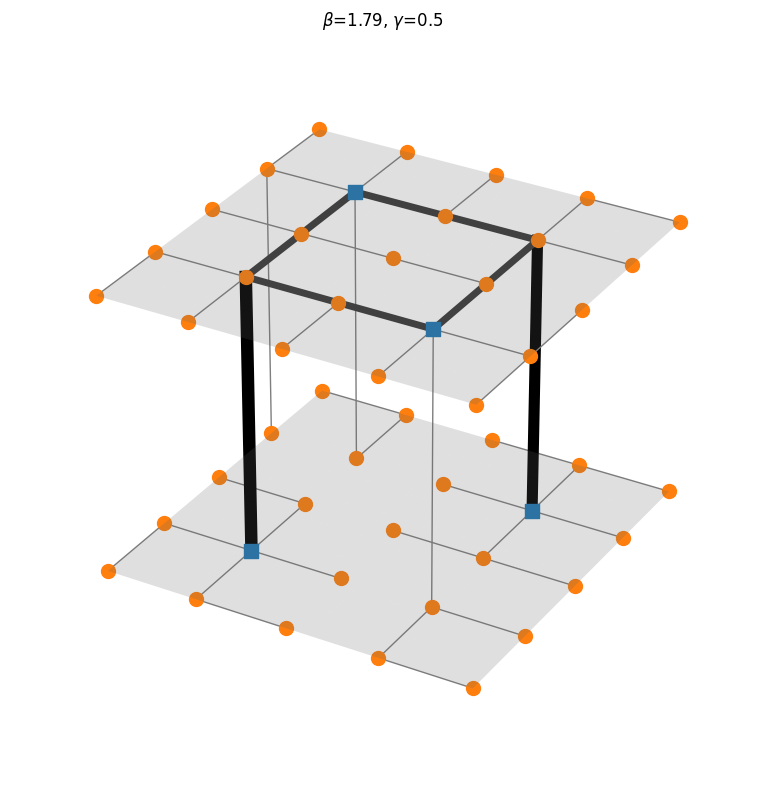

In [10]:
# Generate a multilayer network with standard parameters:
G, pos = multilayer_lattice_network()

# Set the parameters for the second moment matrix and compute it:
mu = 2 / G.number_of_nodes()
beta = 1.79
MSM = compute_second_moment_matrix(G, beta, mu)

# Compute the incidence matrix 
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
E = nx.incidence_matrix(G, oriented=True)

# Compute a minimum dissipation network for the given parameters:
gamma = 0.5
cap_k = 1
k_min, D_min = random_minimum(E, MSM, gamma=gamma, cap_k=cap_k)

# Out put the results:
print(f'Paramters are: gamma = {gamma}, beta = {beta}, kappa = {cap_k}, mu = {mu}.\n')
print(f'The minimum dissipation for given parameters is {D_min}.\n')
print('The edge capacities in the minimum dissipation network are:\n')
print(k_min)

# For the plotting we remove all edges with a capacity below a threshold:
threshold = 1e-9
Gres = G.copy()
for e in range(num_edges):
    f = np.argmax(E[:, [e]])
    t = np.argmin(E[:, [e]])
    if k_min[e] < threshold:
        Gres.remove_edge(f, t)
    else:
        Gres.edges[f, t]["weight"] = k_min[e]

# Plot the network structure:
plot_multilayer_network_3d(Gres, pos, beta, gamma)